<a href="https://colab.research.google.com/github/AnishIdhayan-1412/MiniProject_DS_AIML-B_2026_-AgroPredict/blob/main/notebooks/DS_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# ============================================# AgroPredict - Crop Yield Prediction# ============================================
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
# Ignore warnings (clean output)
import warnings
warnings.filterwarnings('ignore')

In [15]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

# Get uploaded filename automatically
file_name = list(uploaded.keys())[0]
print("Uploaded file:", file_name)

Saving archive (1).zip to archive (1) (1).zip
Uploaded file: archive (1) (1).zip


In [16]:
# Load dataset
data = pd.read_csv(file_name)

print("\n Dataset Preview:")
display(data.head())


 Dataset Preview:


,Fertilizer,temp,N,P,K,yeild
0,80.0,28.0,80.0,24.0,20.0,12.0
1,77.0,27.0,78.0,23.0,20.0,12.0
2,80.0,26.0,80.0,24.0,20.0,12.0
3,80.0,28.0,80.0,24.0,20.0,12.0
4,78.0,27.0,78.0,23.0,19.0,12.0


In [17]:
print("\n Dataset Info:")
display(data.info())

print("\n Missing Values:")
display(data.isnull().sum())

print("\n Statistical Summary:")
display(data.describe())


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2596 entries, 0 to 2595
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fertilizer  2596 non-null   float64
 1   temp        2596 non-null   float64
 2   N           2596 non-null   float64
 3   P           2596 non-null   float64
 4   K           2596 non-null   float64
 5   yeild       2596 non-null   float64
dtypes: float64(6)
memory usage: 121.8 KB


None


 Missing Values:


,0
Fertilizer,0
temp,0
N,0
P,0
K,0
yeild,0



 Statistical Summary:


,Fertilizer,temp,N,P,K,yeild
count,2596.000000,2596.000000,2596.000000,2596.000000,2596.000000,2596.000000
mean,66.487433,33.848237,69.522900,20.708194,17.806268,8.533832
std,9.747669,5.371279,6.802806,1.973419,1.940037,1.938789
min,49.751436,23.771310,58.839466,17.723223,14.704883,5.150745
25%,59.865423,28.000000,64.834635,18.988224,15.975932,6.929404
50%,65.011969,36.965121,69.894076,20.889579,18.061975,8.501720
75%,76.943112,38.928914,76.845919,22.125618,19.133858,10.045179
max,80.223893,40.272480,80.218705,25.162178,22.064666,12.337651


In [18]:
# Remove missing values
data = data.dropna()

# Convert categorical column if exists
if 'crop' in data.columns:
    data = pd.get_dummies(data, columns=['crop'])

print("\n Data cleaned successfully!")


 Data cleaned successfully!


In [19]:
# Show column names
print("Columns:", data.columns)

# Automatically detect target column (if unsure)
possible_targets = ['yield', 'Yield', 'Production', 'label']

target = None
for col in possible_targets:
    if col in data.columns:
        target = col
        break

# If not found, ask manually
if target is None:
    target = input("Enter target column name: ")

print("Selected Target:", target)

# Split features and target
X = data.drop(target, axis=1)
y = data[target]

print("\n Feature Columns:", list(X.columns))

Columns: Index(['Fertilizer', 'temp', 'N', 'P', 'K', 'yeild'], dtype='object')
Enter target column name: yeild
Selected Target: yeild

 Feature Columns: ['Fertilizer', 'temp', 'N', 'P', 'K']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (2076, 5)
Testing size: (520, 5)


In [21]:
# Initialize model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [22]:
# Predict
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\n Model Performance:")
print(f"R2 Score (Accuracy): {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")


 Model Performance:
R2 Score (Accuracy): 0.9908
Mean Squared Error: 0.0347


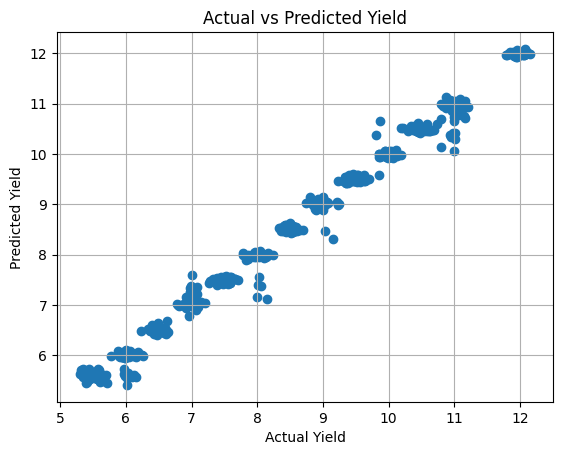

In [23]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.grid()
plt.show()

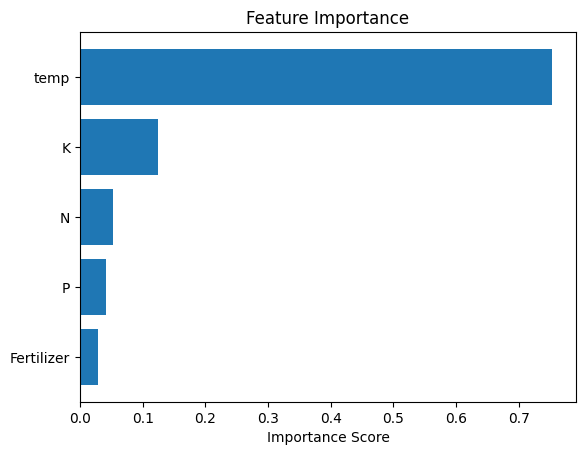

In [24]:
importance = model.feature_importances_
features = X.columns

# Sort for better visualization
sorted_idx = np.argsort(importance)

plt.figure()
plt.barh(features[sorted_idx], importance[sorted_idx])
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [25]:
# Use DataFrame instead of array (no warning)
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("\n Sample Input:")
display(sample)

print(" Predicted Yield:", prediction[0])


 Sample Input:


,Fertilizer,temp,N,P,K
0,80.0,28.0,80.0,24.0,20.0


 Predicted Yield: 11.997392123807602
